# AqSolDB: A curated aqueous solubility dataset
> ## Section 1

### 1. Project Objective 
#####
This project uses the AqSolDB curated aqueous solubility dataset to explore whether molecular descriptors such as molecular weight, LogP, TPSA, hydrogen bonding capacity, and ring structure can be used to predict aqueous solubility.

The target variable is Solubility, and the input features are calculated molecular descriptors. The project is framed as a preformulation decision-support problem rather than only a machine learning exercise.

### Main Question:
####    Can molecular structure help predict solubility and support early formulation decisions?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv(r'E:\Data Science\Projects\Kaggel\AqSolDB A curated aqueous solubility dataset\curated-solubility-dataset.csv')
df.head()

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9982 entries, 0 to 9981
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   9982 non-null   object 
 1   Name                 9982 non-null   object 
 2   InChI                9982 non-null   object 
 3   InChIKey             9982 non-null   object 
 4   SMILES               9982 non-null   object 
 5   Solubility           9982 non-null   float64
 6   SD                   9982 non-null   float64
 7   Ocurrences           9982 non-null   int64  
 8   Group                9982 non-null   object 
 9   MolWt                9982 non-null   float64
 10  MolLogP              9982 non-null   float64
 11  MolMR                9982 non-null   float64
 12  HeavyAtomCount       9982 non-null   float64
 13  NumHAcceptors        9982 non-null   float64
 14  NumHDonors           9982 non-null   float64
 15  NumHeteroatoms       9982 non-null   f

In [6]:
df.shape

(9982, 26)

In [7]:
df.describe()

,Solubility,SD,Ocurrences,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
count,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000
mean,-2.889909,0.067449,1.378081,266.665946,1.979167,66.794594,17.374674,3.486776,1.108595,5.196955,4.073031,94.243438,1.068323,0.292627,0.447606,1.515929,62.458601,108.912586,2.392199,467.336782
std,2.368154,0.234702,1.023476,184.179024,3.517738,46.523021,12.241536,3.498203,1.488973,4.736275,5.646925,64.748563,1.309427,0.879599,1.054667,1.644334,63.348307,76.462726,1.091123,546.631696
min,-13.171900,0.000000,1.000000,9.012000,-40.873200,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.504228,-0.000004,0.000000
25%,-4.326325,0.000000,1.000000,162.276000,0.619750,40.602475,11.000000,2.000000,0.000000,3.000000,1.000000,58.000000,0.000000,0.000000,0.000000,0.000000,26.300000,66.623721,2.004357,163.243343
50%,-2.618173,0.000000,1.000000,228.682000,1.949220,58.633400,15.000000,3.000000,1.000000,4.000000,3.000000,82.000000,1.000000,0.000000,0.000000,1.000000,50.720000,93.299873,2.539539,351.640433
75%,-1.209735,0.000000,1.000000,320.436000,3.419030,81.938000,21.000000,4.000000,2.000000,6.000000,5.000000,112.000000,2.000000,0.000000,1.000000,2.000000,80.390000,129.118374,3.032456,606.562848
max,2.137682,3.870145,38.000000,5299.456000,68.541140,1419.351700,388.000000,86.000000,26.000000,89.000000,141.000000,2012.000000,35.000000,30.000000,30.000000,36.000000,1214.340000,2230.685124,7.517310,20720.267708


In [8]:
df.columns

Index(['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'Solubility', 'SD',
       'Ocurrences', 'Group', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount',
       'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds',
       'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings',
       'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ',
       'BertzCT'],
      dtype='object')

In [9]:
df.sample(5, random_state=42)

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
1253,A-2169,"2-ethyl-9,10-dihydroanthracene-9,10-dione",InChI=1S/C16H12O2/c1-2-10-7-8-13-14(9-10)16(18...,SJEBAWHUJDUKQK-UHFFFAOYSA-N,CCc1ccc2C(=O)c3ccccc3C(=O)c2c1,-5.984242,0.000000,1,G1,236.270,...,1.0,88.0,2.0,0.0,1.0,3.0,34.14,105.265479,2.268429,668.547220
9930,H-553,Digoxin,InChI=1S/C41H64O14/c1-19-36(47)28(42)15-34(50-...,LTMHDMANZUZIPE-UHFFFAOYSA-N,CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,-4.160000,0.158641,3,G5,780.949,...,7.0,312.0,0.0,7.0,8.0,8.0,203.06,323.322425,0.837498,1409.003742
7046,B-4401,diphenic acid,InChI=1S/C14H10O4/c15-13(16)11-7-3-1-5-9(11)10...,GWZCCUDJHOGOSO-UHFFFAOYSA-N,OC(=O)c1ccccc1c2ccccc2C(O)=O,-2.283900,0.000000,1,G1,242.230,...,3.0,90.0,2.0,0.0,0.0,2.0,74.60,103.129893,2.697464,561.195986
8711,E-148,pentachlorobutadiene,InChI=1S/C4HCl5/c5-2(4(8)9)1-3(6)7/h1H,WVFBDVFCOCLEFM-UHFFFAOYSA-N,ClC(=C(C=C(Cl)Cl)Cl)Cl,-4.230000,0.000000,1,G1,226.317,...,1.0,52.0,0.0,0.0,0.0,0.0,0.00,77.971202,4.249516,148.340930
6880,B-4164,trimethyl phosphate,"InChI=1S/C3H9O4P/c1-5-8(4,6-2)7-3/h1-3H3",WVLBCYQITXONBZ-UHFFFAOYSA-N,CO[P](=O)(OC)OC,0.552600,0.000000,1,G1,140.075,...,3.0,50.0,0.0,0.0,0.0,0.0,44.76,48.359382,3.791010,82.436995


Type |	Purpose|
-----------|--------------
Identity columns |	Track the compound
Target column |	Value we want to predict
Descriptor columns |	Features used for prediction
Metadata columns |	Extra experimental/context information

In [10]:
identity_columns = ["ID", "Name", "InChI", "InChIKey", "SMILES"]

target_column = "Solubility"

metadata_columns = ["SD", "Ocurrences", "Group"]

descriptor_columns = [
    "MolWt",
    "MolLogP",
    "MolMR",
    "HeavyAtomCount",
    "NumHAcceptors",
    "NumHDonors",
    "NumHeteroatoms",
    "NumRotatableBonds",
    "NumValenceElectrons",
    "NumAromaticRings",
    "NumSaturatedRings",
    "NumAliphaticRings",
    "RingCount",
    "TPSA",
    "LabuteASA",
    "BalabanJ",
    "BertzCT"
]

In [11]:
print("Identity columns:", identity_columns)
print("Target column:", target_column)
print("Metadata columns:", metadata_columns)
print("Descriptor columns:", descriptor_columns)
print("Number of descriptor columns:", len(descriptor_columns))

Identity columns: ['ID', 'Name', 'InChI', 'InChIKey', 'SMILES']
Target column: Solubility
Metadata columns: ['SD', 'Ocurrences', 'Group']
Descriptor columns: ['MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ', 'BertzCT']
Number of descriptor columns: 17


In [12]:
df[identity_columns].dtypes

ID          object
Name        object
InChI       object
InChIKey    object
SMILES      object
dtype: object

In [13]:
df[target_column].dtypes

dtype('float64')

In [14]:
df[metadata_columns].dtypes

SD            float64
Ocurrences      int64
Group          object
dtype: object

In [15]:
df[descriptor_columns].dtypes

MolWt                  float64
MolLogP                float64
MolMR                  float64
HeavyAtomCount         float64
NumHAcceptors          float64
NumHDonors             float64
NumHeteroatoms         float64
NumRotatableBonds      float64
NumValenceElectrons    float64
NumAromaticRings       float64
NumSaturatedRings      float64
NumAliphaticRings      float64
RingCount              float64
TPSA                   float64
LabuteASA              float64
BalabanJ               float64
BertzCT                float64
dtype: object

Input features = descriptor columns only

Target = Solubility

Excluded from modelling = identity columns and metadata columns

In [16]:
df.isnull().sum()

ID                     0
Name                   0
InChI                  0
InChIKey               0
SMILES                 0
Solubility             0
SD                     0
Ocurrences             0
Group                  0
MolWt                  0
MolLogP                0
MolMR                  0
HeavyAtomCount         0
NumHAcceptors          0
NumHDonors             0
NumHeteroatoms         0
NumRotatableBonds      0
NumValenceElectrons    0
NumAromaticRings       0
NumSaturatedRings      0
NumAliphaticRings      0
RingCount              0
TPSA                   0
LabuteASA              0
BalabanJ               0
BertzCT                0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
# check for duplicates in the InChIKey column, which should be unique for each compound

df["InChIKey"].duplicated().sum()

np.int64(0)

In [19]:
df[target_column].describe()

count    9982.000000
mean       -2.889909
std         2.368154
min       -13.171900
25%        -4.326325
50%        -2.618173
75%        -1.209735
max         2.137682
Name: Solubility, dtype: float64

In [22]:
df[descriptor_columns].describe()

,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
count,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000
mean,266.665946,1.979167,66.794594,17.374674,3.486776,1.108595,5.196955,4.073031,94.243438,1.068323,0.292627,0.447606,1.515929,62.458601,108.912586,2.392199,467.336782
std,184.179024,3.517738,46.523021,12.241536,3.498203,1.488973,4.736275,5.646925,64.748563,1.309427,0.879599,1.054667,1.644334,63.348307,76.462726,1.091123,546.631696
min,9.012000,-40.873200,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.504228,-0.000004,0.000000
25%,162.276000,0.619750,40.602475,11.000000,2.000000,0.000000,3.000000,1.000000,58.000000,0.000000,0.000000,0.000000,0.000000,26.300000,66.623721,2.004357,163.243343
50%,228.682000,1.949220,58.633400,15.000000,3.000000,1.000000,4.000000,3.000000,82.000000,1.000000,0.000000,0.000000,1.000000,50.720000,93.299873,2.539539,351.640433
75%,320.436000,3.419030,81.938000,21.000000,4.000000,2.000000,6.000000,5.000000,112.000000,2.000000,0.000000,1.000000,2.000000,80.390000,129.118374,3.032456,606.562848
max,5299.456000,68.541140,1419.351700,388.000000,86.000000,26.000000,89.000000,141.000000,2012.000000,35.000000,30.000000,30.000000,36.000000,1214.340000,2230.685124,7.517310,20720.267708


In [23]:
df[descriptor_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
MolWt,9982.0,266.665946,184.179024,9.012000,162.276000,228.682000,320.436000,5299.456000
MolLogP,9982.0,1.979167,3.517738,-40.873200,0.619750,1.949220,3.419030,68.541140
MolMR,9982.0,66.794594,46.523021,0.000000,40.602475,58.633400,81.938000,1419.351700
HeavyAtomCount,9982.0,17.374674,12.241536,1.000000,11.000000,15.000000,21.000000,388.000000
NumHAcceptors,9982.0,3.486776,3.498203,0.000000,2.000000,3.000000,4.000000,86.000000
NumHDonors,9982.0,1.108595,1.488973,0.000000,0.000000,1.000000,2.000000,26.000000
NumHeteroatoms,9982.0,5.196955,4.736275,0.000000,3.000000,4.000000,6.000000,89.000000
NumRotatableBonds,9982.0,4.073031,5.646925,0.000000,1.000000,3.000000,5.000000,141.000000
NumValenceElectrons,9982.0,94.243438,64.748563,0.000000,58.000000,82.000000,112.000000,2012.000000
NumAromaticRings,9982.0,1.068323,1.309427,0.000000,0.000000,1.000000,2.000000,35.000000


In [24]:
df.sort_values("Solubility").head(10)[
    ["Name", "SMILES", "Solubility", "MolWt", "MolLogP", "TPSA"]
]

,Name,SMILES,Solubility,MolWt,MolLogP,TPSA
5528,dechlorane plus,ClC1=C(Cl)C2(Cl)C3CCC4C(CCC3C1(Cl)C2(Cl)Cl)C5(...,-13.171900,653.730,9.7162,0.00
9875,Decachlorodiphenyl ether,ClC1=C(Cl)C(Cl)=C(OC2=C(Cl)C(Cl)=C(Cl)C(Cl)=C2...,-12.950000,514.661,10.0129,9.23
7058,"1,2,3,4,6,7,8,9-octachlorodibenzo-p-dioxin",Clc1c(Cl)c(Cl)c2Oc3c(Cl)c(Cl)c(Cl)c(Cl)c3Oc2c1Cl,-12.060500,459.754,8.8118,18.46
1362,copper(2+) ion bis((9Z)-octadec-9-enoate),[Cu++].CCCCCCCC\C=C/CCCCCCCC([O-])=O.CCCCCCCC\...,-11.998938,626.466,9.5451,80.26
9740,"2,2',3,3',4,4',5,5',6,6'-PCB",Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...,-11.600000,498.662,9.8876,0.00
5928,octachlorodibenzofuran,Clc1c(Cl)c(Cl)c2c(oc3c(Cl)c(Cl)c(Cl)c(Cl)c23)c1Cl,-11.582700,443.755,8.8132,13.14
6166,"dibenzofuran, 1,2,3,4,6,7,8-heptachloro-",Clc1cc2c(oc3c(Cl)c(Cl)c(Cl)c(Cl)c23)c(Cl)c1Cl,-11.481700,409.310,8.1598,13.14
5904,heptachlorodibenzo-p-dioxin,Clc1cc2Oc3c(Cl)c(Cl)c(Cl)c(Cl)c3Oc2c(Cl)c1Cl,-11.479500,425.309,8.1584,18.46
7061,"1,2,3,4,7,8-hexachlorodibenzo-p-dioxin",Clc1cc2Oc3c(Cl)c(Cl)c(Cl)c(Cl)c3Oc2cc1Cl,-10.948600,390.864,7.5050,18.46
9886,"1,2,3,4,7,8-Hexachlorodibenzofuran",ClC1=C(Cl)C=C2C(=C1)OC1=C(Cl)C(Cl)=C(Cl)C(Cl)=C21,-10.660000,374.865,7.5064,13.14


In [25]:
df.sort_values("Solubility", ascending=False).head(10)[
    ["Name", "SMILES", "Solubility", "MolWt", "MolLogP", "TPSA"]
]

,Name,SMILES,Solubility,MolWt,MolLogP,TPSA
1777,4-methyl-2-(2-methylpropyl)oxan-4-ol,CC(C)CC1CC(C)(O)CCO1,2.137682,172.268,1.9625,29.46
1755,bis(tetrakis(hydroxymethyl)phosphanium) sulfate,OC[P+](CO)(CO)CO.OC[P+](CO)(CO)CO.[O-][S]([O-]...,1.967513,406.283,-3.7316,242.10
1948,ammonium bromide,[NH4+].[Br-],1.908300,97.943,-2.6198,36.50
2513,azanium 2-hydroxyacetate,[NH4+].OCC([O-])=O,1.700916,93.082,-1.8952,96.86
5457,hydrogen fluoride,[H+].[F-],1.698800,20.006,-2.8835,0.00
2512,"2-Hydroxy-N,N-dimethylpropanamide",CC(O)C(=O)N(C)C,1.630235,117.148,-0.5446,40.54
2122,"hexane-1,6-diol",OCCCCCCO,1.626441,118.176,0.5314,40.46
1771,hydrazine dihydrochloride,[H+].[Cl-].NN,1.595629,68.507,-4.0647,52.04
863,9-[2-(2-methoxyethoxy)ethoxy]-9-[3-(oxiran-2-y...,COCCOCCO[Si](CCCOCC1CO1)(OCCOCCOC)OCCOCCOC,1.582313,500.658,0.7696,104.83
3717,acetamide,CC(N)=O,1.580800,59.068,-0.5084,43.09


In [26]:
df.sort_values("MolWt", ascending=False).head(10)[
    ["Name", "Solubility", "MolWt", "MolLogP", "TPSA"]
]

,Name,Solubility,MolWt,MolLogP,TPSA
1523,"1,4-xylene 4-(methoxycarbonyl)benzoic acid 4-m...",-6.731678,5299.456,49.35298,1214.34
1920,hexasodium; dioxido-dioxotungsten; trioxotungsten,-0.472461,2967.981,-29.06040,701.67
1232,"1,3-dimethyl-5-propylbenzene; 6,6,22,22-tetrab...",-6.806303,2560.723,68.54114,0.00
2597,decasodium 2-[(E)-2-{2-sulfonato-4-[(E)-2-{3-s...,-1.231546,2420.104,-9.29600,794.48
1204,"dialuminium tris[2-(2,4,5,7-tetrabromo-6-oxido...",-6.490069,2404.941,22.23490,280.20
1462,"N,N',N'',N'''-tetrakis(4,6-bis(butyl-(N-methyl...",-5.359015,2285.676,25.80720,237.06
1208,"3,3,4,4,5,5,6,6,7,7,8,8,8-tridecafluorooctyl p...",-6.481477,2272.680,27.00160,105.20
3492,2-[(E)-2-(2-chloro-4-{3-chloro-4-[(E)-2-{1-[(2...,-9.052341,2256.165,27.92352,480.72
110,{2-hydroxy-3-[(9Z)-octadec-9-enoyloxy]propoxy}...,-5.345705,2216.691,29.64000,395.25
1273,"dialuminium tris[2-(2,4,5,7-tetrabromo-6-oxido...",-7.143563,1991.601,14.39410,280.20


In [28]:
df.sort_values("MolLogP", ascending=False).head(10)[
    ["Name", "Solubility", "MolWt", "MolLogP", "TPSA"]
]

,Name,Solubility,MolWt,MolLogP,TPSA
1232,"1,3-dimethyl-5-propylbenzene; 6,6,22,22-tetrab...",-6.806303,2560.723,68.54114,0.00
1523,"1,4-xylene 4-(methoxycarbonyl)benzoic acid 4-m...",-6.731678,5299.456,49.35298,1214.34
324,"1,3-xylene; 1,4-diethylcyclohexane; 8,15-dieth...",-5.405053,1590.844,40.75184,0.00
465,(2-phenylbutan-2-yl)benzene; (2-phenylethyl)be...,-4.588177,1588.403,33.96896,0.00
1657,"methyl (9E,12E,15E)-octadeca-9,12,15-trienoate...",-7.800360,1452.405,29.98030,131.50
110,{2-hydroxy-3-[(9Z)-octadec-9-enoyloxy]propoxy}...,-5.345705,2216.691,29.64000,395.25
3492,2-[(E)-2-(2-chloro-4-{3-chloro-4-[(E)-2-{1-[(2...,-9.052341,2256.165,27.92352,480.72
1208,"3,3,4,4,5,5,6,6,7,7,8,8,8-tridecafluorooctyl p...",-6.481477,2272.680,27.00160,105.20
1246,"3-[(7Z)-pentadec-7-en-1-yl]phenol; 3-[(7Z,10Z)...",-6.597039,1205.976,26.75960,80.92
1695,"(1E,19E)-10,11-dioctylicosa-1,19-diene-1,20-di...",-9.707106,1018.911,26.24660,12.03


In [29]:
df.sort_values("TPSA", ascending=False).head(10)[
    ["Name", "Solubility", "MolWt", "MolLogP", "TPSA"]
]

,Name,Solubility,MolWt,MolLogP,TPSA
1523,"1,4-xylene 4-(methoxycarbonyl)benzoic acid 4-m...",-6.731678,5299.456,49.35298,1214.34
3149,"(2R,3R,4R,5R)-hexane-1,2,3,4,5,6-hexol; (2S,3S...",-0.589206,1941.672,-16.96780,1017.84
2451,azane; molybdenum; tetracosahydrate,-0.766473,1206.126,-18.83830,966.00
2597,decasodium 2-[(E)-2-{2-sulfonato-4-[(E)-2-{3-s...,-1.231546,2420.104,-9.29600,794.48
1723,"octasodium 7,7'-[(2,2'-disulphonato[1,1'-biphe...",-1.498168,1834.274,-18.61200,742.74
1341,oxygen(-2) anion; vanadium; pentahydroxide; pe...,-1.350364,945.532,-15.61600,723.75
1920,hexasodium; dioxido-dioxotungsten; trioxotungsten,-0.472461,2967.981,-29.06040,701.67
1376,2-hydroxypropanoic acid; 5-({bis[(2-aminopropy...,-0.794219,1618.797,6.38320,696.51
2427,disodium bis[(oxoboranyl)oxy]bicyclo[5.5.1]hex...,-0.420186,588.512,-40.87320,679.44
1749,"octasodium 2,2'-{1,4-phenylenebis[imino(6-chlo...",-0.634868,1774.214,-17.54260,672.96


## Exploratory Data Analysis

####    Understand the scientific relationships in the dataset before modelling.

#####       * What is the distribution of solubility?
#####       * Which descriptors are related to solubility?
#####       * Are there clear chemical trends?
#####       * Are any descriptors strongly correlated with each other?

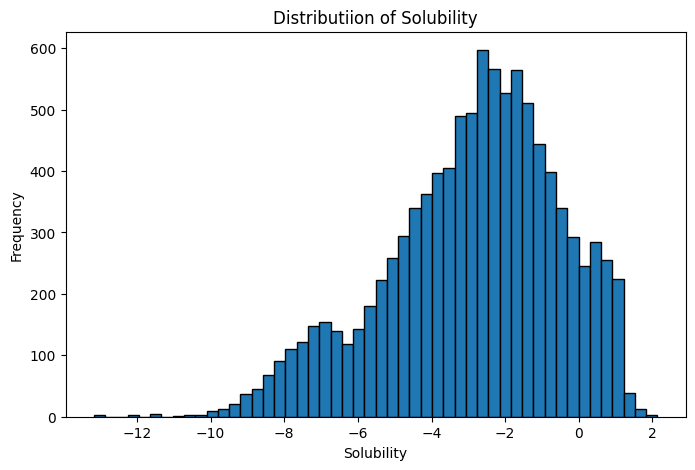

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df['Solubility'], bins=50, edgecolor = 'black')
plt.xlabel('Solubility')
plt.ylabel('Frequency')
plt.title('Distributiion of Solubility')
plt.show()

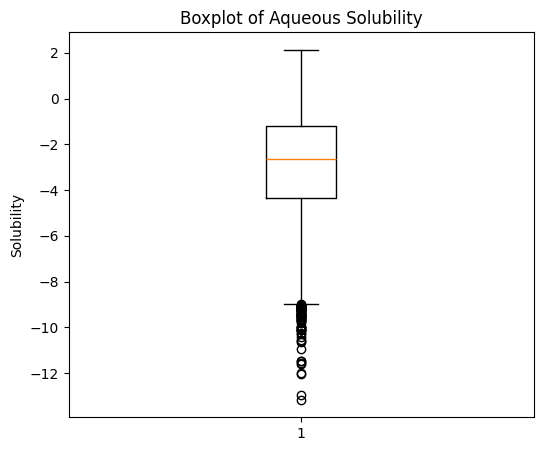

In [34]:
plt.figure(figsize=(6,5))
plt.boxplot(df["Solubility"])
plt.ylabel("Solubility")
plt.title("Boxplot of Aqueous Solubility")
plt.show()

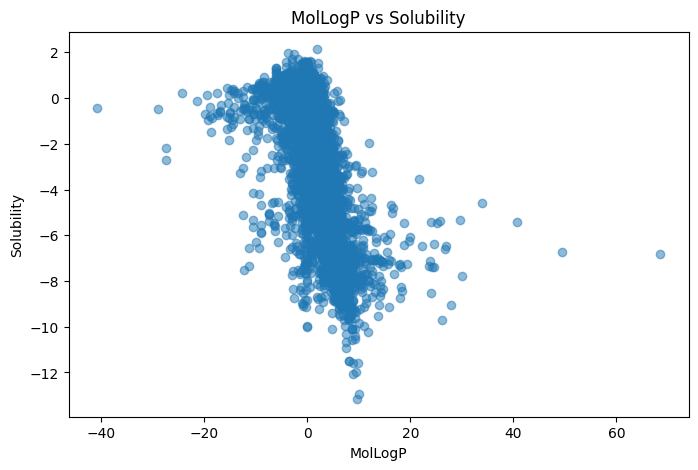

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(df["MolLogP"], df["Solubility"], alpha=0.5)
plt.xlabel("MolLogP")
plt.ylabel("Solubility")
plt.title("MolLogP vs Solubility")
plt.show()

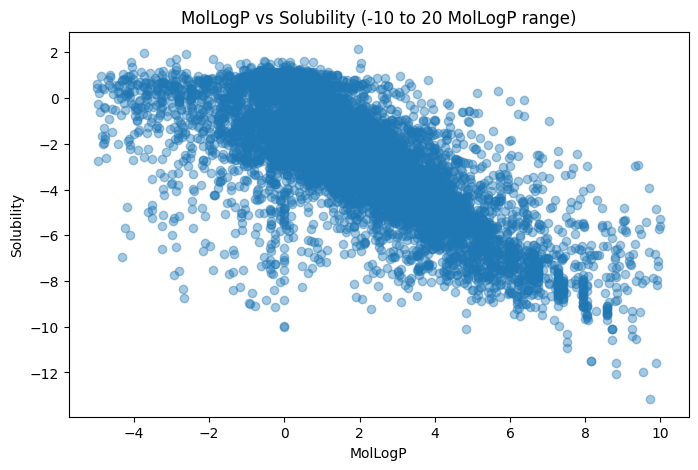

In [53]:
filtered_df = df[(df["MolLogP"] >= -5) & (df["MolLogP"] <= 10)]

plt.figure(figsize=(8,5))
plt.scatter(filtered_df["MolLogP"], filtered_df["Solubility"], alpha=0.4)
plt.xlabel("MolLogP")
plt.ylabel("Solubility")
plt.title("MolLogP vs Solubility (-10 to 20 MolLogP range)")
plt.show()

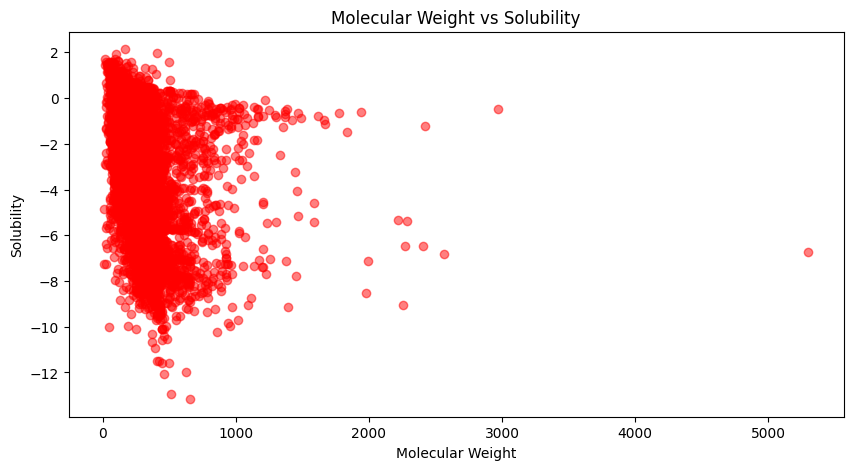

In [41]:
plt.figure(figsize=(10,5))
plt.scatter(df['MolWt'], df['Solubility'], alpha=0.5, color = 'red')
plt.xlabel("Molecular Weight")
plt.ylabel("Solubility")
plt.title("Molecular Weight vs Solubility")
plt.show()

<b> Higher molecular weight is generally associated with lower solubility, but the relationship is weak to moderate and not cleanly linear. <b>

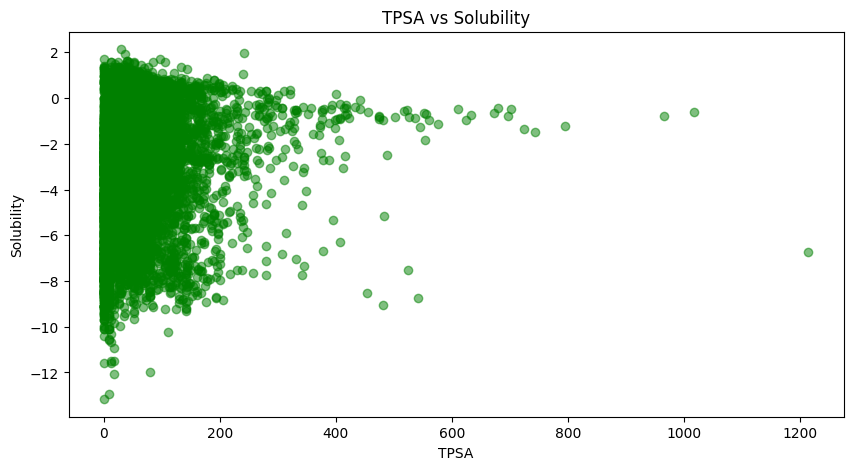

In [42]:
plt.figure(figsize=(10,5))
plt.scatter(df['TPSA'], df['Solubility'], alpha=0.5, color='green')
plt.xlabel("TPSA")
plt.ylabel("Solubility")
plt.title("TPSA vs Solubility")
plt.show()

<b> TPSA has only a weak positive relationship with solubility. Higher polarity may help water interaction, but TPSA alone is not enough to predict solubility reliably. <b>

In [46]:
# how strongly each molecular descriptor is related to Solubility.

corr_with_solubility = df[descriptor_columns + ["Solubility"]].corr()["Solubility"].sort_values(ascending=False)
corr_with_solubility

Solubility             1.000000
NumHDonors             0.193066
TPSA                   0.111662
NumHAcceptors          0.040020
BalabanJ               0.037329
NumSaturatedRings     -0.037794
NumHeteroatoms        -0.040432
NumAliphaticRings     -0.087706
NumRotatableBonds     -0.222040
BertzCT               -0.289403
RingCount             -0.329599
NumAromaticRings      -0.343257
NumValenceElectrons   -0.346369
LabuteASA             -0.349497
HeavyAtomCount        -0.352748
MolWt                 -0.368032
MolMR                 -0.424452
MolLogP               -0.608580
Name: Solubility, dtype: float64

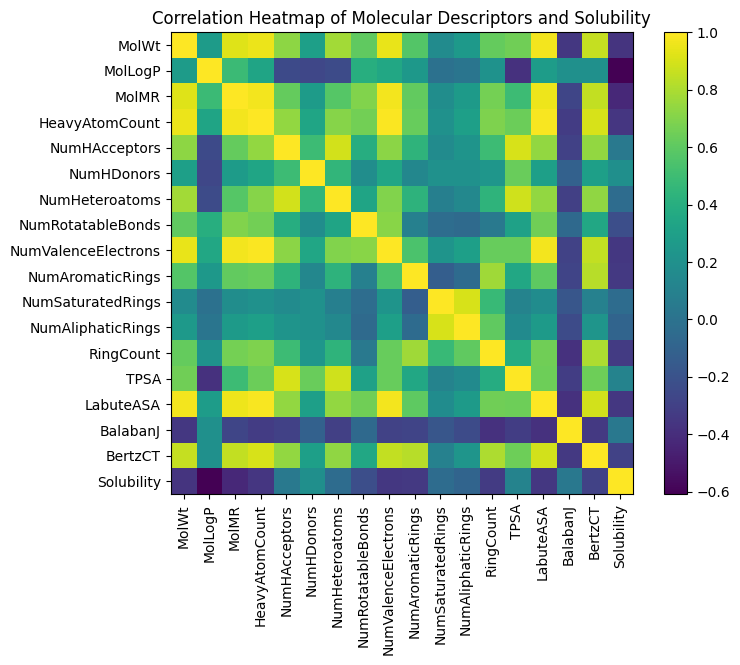

In [51]:
corr_matrix = df[descriptor_columns + ["Solubility"]].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Molecular Descriptors and Solubility")
plt.show()

# Feature selection and preprocessing

In [54]:
X = df[descriptor_columns]
y = df['Solubility']

In [57]:
print("X.Shape: ", X.shape)
print("y Shape: ", y.shape)

X.Shape:  (9982, 17)
y Shape:  (9982,)


In [58]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= 42
)


In [62]:
X_train.head()

,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
3397,556.668,5.72830,84.9350,17.0,2.0,0.0,7.0,3.0,92.0,1.0,0.0,0.0,1.0,26.30,140.814374,3.156668,455.069981
7794,396.004,5.29970,85.4815,20.0,3.0,0.0,7.0,4.0,106.0,2.0,0.0,0.0,2.0,35.53,135.017550,2.410609,664.165886
1298,270.284,3.23224,73.1890,20.0,4.0,0.0,4.0,2.0,102.0,2.0,0.0,0.0,2.0,52.60,116.427696,1.943758,554.430061
6113,160.169,0.50110,37.8610,11.0,4.0,0.0,4.0,3.0,64.0,0.0,0.0,0.0,0.0,52.60,65.479038,3.766309,152.519563
8263,336.392,1.29490,89.6830,24.0,8.0,0.0,8.0,8.0,132.0,2.0,0.0,0.0,2.0,88.12,139.223561,2.025903,830.940594


In [63]:
y_train.head()

3397   -7.806077
7794   -4.990000
1298   -6.798352
6113   -0.862200
8263   -3.450000
Name: Solubility, dtype: float64

In [65]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7985, 17)
X_test: (1997, 17)
y_train: (7985,)
y_test: (1997,)


In [66]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [67]:
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)

In [68]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

In [69]:
dummy_mae = mean_absolute_error(y_test, dummy_pred)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_pred))
dummy_r2 = r2_score(y_test, dummy_pred)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

In [70]:
baseline_results = pd.DataFrame({
    "Model": ["Mean Baseline", "Linear Regression"],
    "MAE": [dummy_mae, linear_mae],
    "RMSE": [dummy_rmse, linear_rmse],
    "R2": [dummy_r2, linear_r2]
})

baseline_results

,Model,MAE,RMSE,R2
0,Mean Baseline,1.876758,2.329268,-0.000155
1,Linear Regression,1.212715,1.654348,0.495476


The mean baseline is basically useless for prediction. It only predicts the average solubility for every compound.

R² close to zero means: predicting the mean explains almost none of the variation in solubility.

This is clearly better than the baseline.

What it means: Linear Regression reduced the average prediction error from: 1.88 → 1.21 logS unitsو and improved R² from: ~0 → 0.495

So the molecular descriptors do contain useful information for predicting solubility.

Scientific interpretation: The Linear Regression model explains about 49.5% of the variation in solubility.
That is decent for a first simple model, but not strong enough as a final predictive tool.

In [71]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [72]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

<b> Why Random Forest? <b>


Random Forest builds many decision trees and averages them.

In [73]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

<b>Why Gradient Boosting?<b>

Gradient Boosting builds trees sequentially. Each new tree tries to correct the errors of the previous trees.

It is often strong for structured/tabular datasets like this.

In [74]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

In [75]:
model_results = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        dummy_mae,
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        dummy_rmse,
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        dummy_r2,
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

model_results.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
2,Random Forest,0.747019,1.083675,0.783515
3,Gradient Boosting,0.838615,1.170303,0.747521
1,Linear Regression,1.212715,1.654348,0.495476
0,Mean Baseline,1.876758,2.329268,-0.000155


1. MAE = 0.747

MAE means: On average, the Random Forest prediction is wrong by about 0.747 logS units.

So if the real solubility is: -3.00, a typical prediction error may be around: ±0.75 logS units

2. RMSE = 1.084

RMSE also measures prediction error, but it punishes large mistakes more than MAE.

Random Forest RMSE: 1.084 means the model sometimes makes larger errors, but overall the large-error behaviour is still better than the other models.

3. R² = 0.784

R² means: Random Forest explains about 78.4% of the variation in Solubility.

This is strong compared with Linear Regression and baseline.

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,MolLogP,0.650936
16,BertzCT,0.072090
0,MolWt,0.047473
15,BalabanJ,0.043094
2,MolMR,0.038681
13,TPSA,0.033105
14,LabuteASA,0.024044
7,NumRotatableBonds,0.017823
6,NumHeteroatoms,0.017772
8,NumValenceElectrons,0.016507


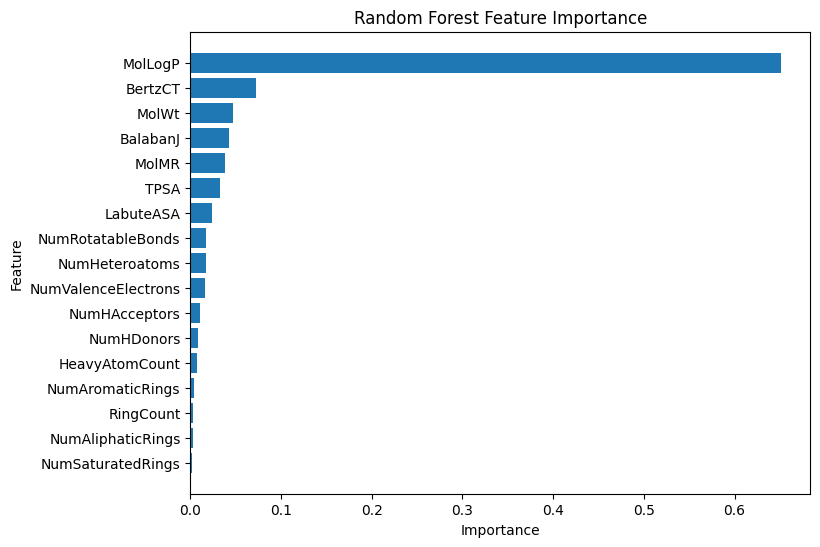

In [77]:
plt.figure(figsize=(8,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

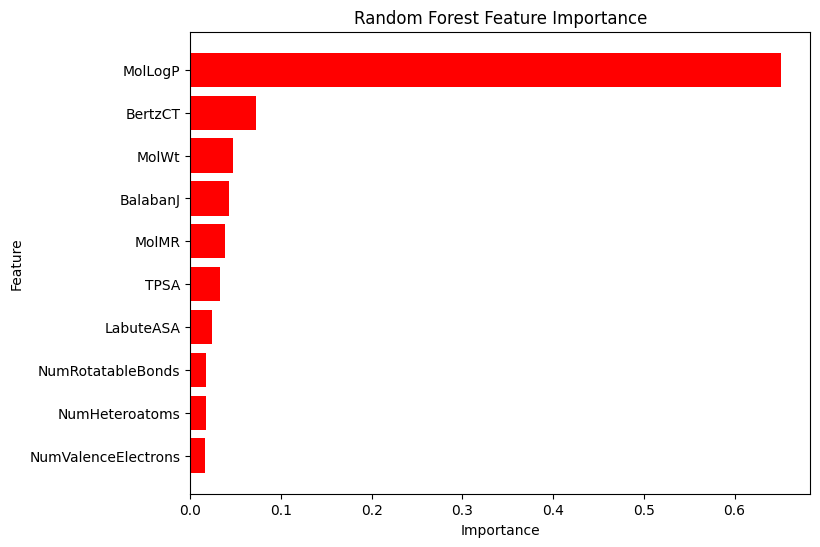

In [80]:
top_10_features = feature_importance.head(10)
plt.figure(figsize=(8,6))
plt.barh(top_10_features["Feature"], top_10_features["Importance"], color= 'red')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Prediction quality and error analysis

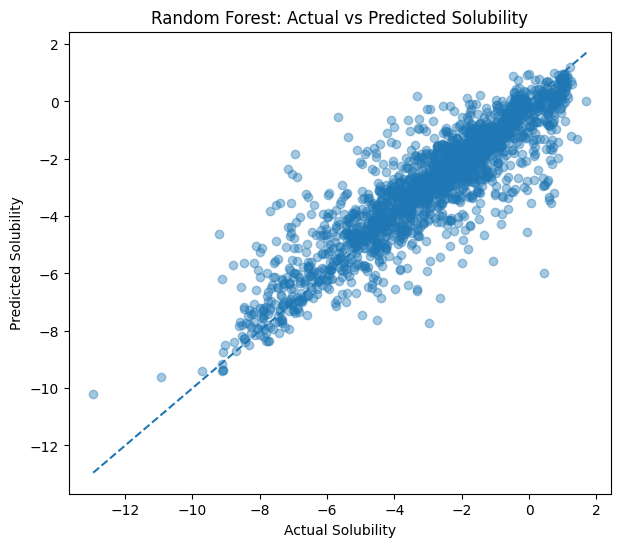

In [81]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, rf_pred, alpha=0.4)
plt.xlabel("Actual Solubility")
plt.ylabel("Predicted Solubility")
plt.title("Random Forest: Actual vs Predicted Solubility")

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

1. Actual vs Predicted plot

Most points follow the dashed diagonal line, which means: Predicted solubility is generally close to actual solubility.

This supports your R² result of about 0.78.

However, the model is not perfect. You can see more scatter around the line in the middle and low-solubility regions.

In [82]:
residuals = y_test - rf_pred

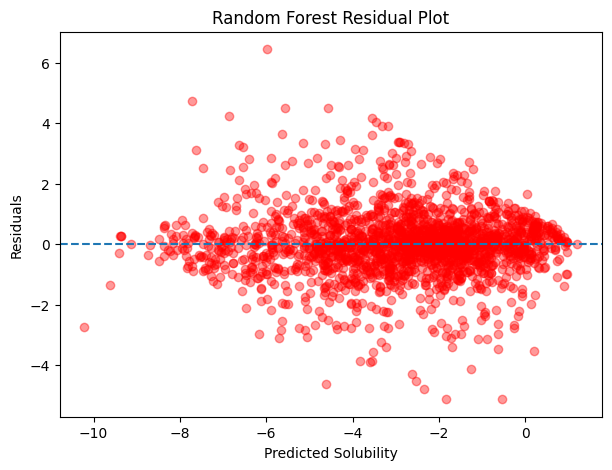

In [83]:
plt.figure(figsize=(7,5))
plt.scatter(rf_pred, residuals, alpha=0.4, color = 'r')
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Solubility")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")
plt.show()

2. Residual plot

Residuals are mostly centred around zero, which is good. That means the model does not show a strong overall bias.

But the spread is wider when predicted solubility is around: -6 to -2

This means the model makes larger errors for some compounds in this range. Also, there are some clear outliers with residuals above +4 or below -4.

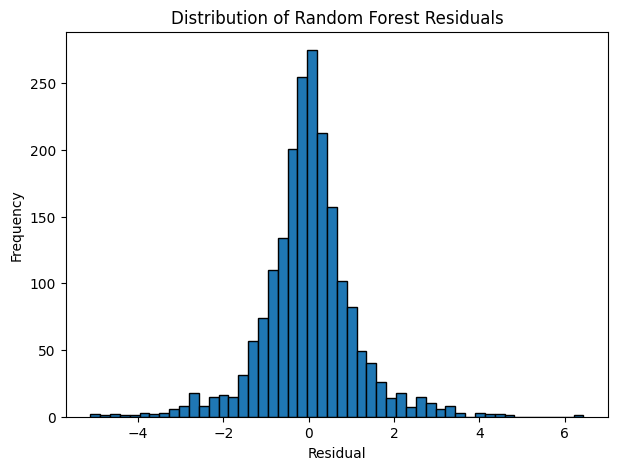

In [84]:
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Random Forest Residuals")
plt.show()

3. Residual histogram

The residuals are mostly centred around zero and roughly bell-shaped. This is a good sign.

It means: most prediction errors are small
the model is not heavily biased toward overprediction or underprediction

But the histogram has tails on both sides, meaning there are some large errors.

The right tail is slightly extended, including one large positive residual.

Positive residual means: Actual solubility > predicted solubility

So for those compounds, the model underpredicted solubility.

In [85]:
error_analysis = X_test.copy()
error_analysis["Actual_Solubility"] = y_test
error_analysis["Predicted_Solubility"] = rf_pred
error_analysis["Residual"] = residuals
error_analysis["Absolute_Error"] = abs(residuals)

largest_errors = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

largest_errors

,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,...,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT,Actual_Solubility,Predicted_Solubility,Residual,Absolute_Error
3107,351.802,1.90290,76.6260,21.0,4.0,0.0,5.0,10.0,120.0,0.0,...,0.0,0.0,80.26,142.014054,-2.945454e-07,230.661531,0.455435,-5.988742,6.444178,6.444178
1536,140.286,-2.41720,24.6180,7.0,4.0,0.0,7.0,0.0,32.0,0.0,...,13.0,13.0,12.96,42.481028,2.424366e+00,183.231833,-5.669893,-0.546875,-5.123018,5.123018
1623,452.629,3.58520,122.0338,31.0,6.0,6.0,8.0,18.0,188.0,0.0,...,0.0,0.0,155.52,187.868087,-3.839234e-07,366.262986,-6.956772,-1.840953,-5.115819,5.115819
1662,285.837,0.94942,35.7928,15.0,6.0,1.0,9.0,0.0,79.0,0.0,...,0.0,0.0,179.24,111.275586,-3.956044e-09,96.500750,-7.155088,-2.355555,-4.799534,4.799534
8345,254.332,5.24480,86.3680,20.0,0.0,0.0,0.0,0.0,94.0,4.0,...,1.0,5.0,0.00,117.200450,2.070952e+00,992.785995,-2.970000,-7.711586,4.741586,4.741586
3555,371.345,2.30170,94.2952,27.0,8.0,2.0,8.0,5.0,140.0,2.0,...,1.0,3.0,125.15,153.996587,1.861692e+00,935.895676,-9.219530,-4.611173,-4.608357,4.608357
1314,221.501,2.80740,60.4800,12.0,2.0,0.0,5.0,4.0,73.0,0.0,...,0.0,0.0,18.46,80.388945,3.830355e+00,120.567365,-7.044346,-2.530441,-4.513905,4.513905
1426,458.375,2.23320,108.9209,33.0,11.0,8.0,11.0,3.0,172.0,3.0,...,1.0,4.0,197.37,184.742011,1.747261e+00,1221.427404,-1.059161,-5.562645,4.503484,4.503484
2107,629.373,6.38130,92.8056,38.0,3.0,0.0,22.0,11.0,232.0,0.0,...,0.0,0.0,57.20,203.631757,0.000000e+00,877.874325,-0.072181,-4.560163,4.487983,4.487983
1599,402.572,3.49240,109.0314,28.0,6.0,3.0,6.0,17.0,166.0,0.0,...,1.0,1.0,96.22,170.168518,1.863690e+00,389.223267,-6.905874,-2.632909,-4.272964,4.272964


>> ## ***Author:*** Sam Pharmed [Kaggle](https://www.kaggle.com/sampharmed), [GitHub](https://github.com/Samb-pharmed)  
>> **Date:** 19 April 2026  
>> **Dataset:** [AqSolDB: A curated aqueous solubility dataset](https://www.kaggle.com/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset)   